vmc Ref shape: (140, 84, 112)
Found 33 files to process.
Processing File 1/33 - Samples: 110100480
Processing File 2/33 - Samples: 143360
Processing File 3/33 - Samples: 430080
Processing File 4/33 - Samples: 35840
Processing File 5/33 - Samples: 4587520
Processing File 6/33 - Samples: 165150720
Processing File 7/33 - Samples: 9175040
Processing File 8/33 - Samples: 573440
Processing File 9/33 - Samples: 36700160
Processing File 10/33 - Samples: 2642411520
Processing File 11/33 - Samples: 440401920
Processing File 12/33 - Samples: 5160960
Processing File 13/33 - Samples: 5284823040
Processing File 14/33 - Samples: 1146880
Processing File 15/33 - Samples: 330301440
Processing File 16/33 - Samples: 2293760
Processing File 17/33 - Samples: 860160
Processing File 18/33 - Samples: 27525120
Processing File 19/33 - Samples: 71680
Processing File 20/33 - Samples: 286720
Processing File 21/33 - Samples: 1321205760
Processing File 22/33 - Samples: 1720320
Processing File 23/33 - Samples: 1376256

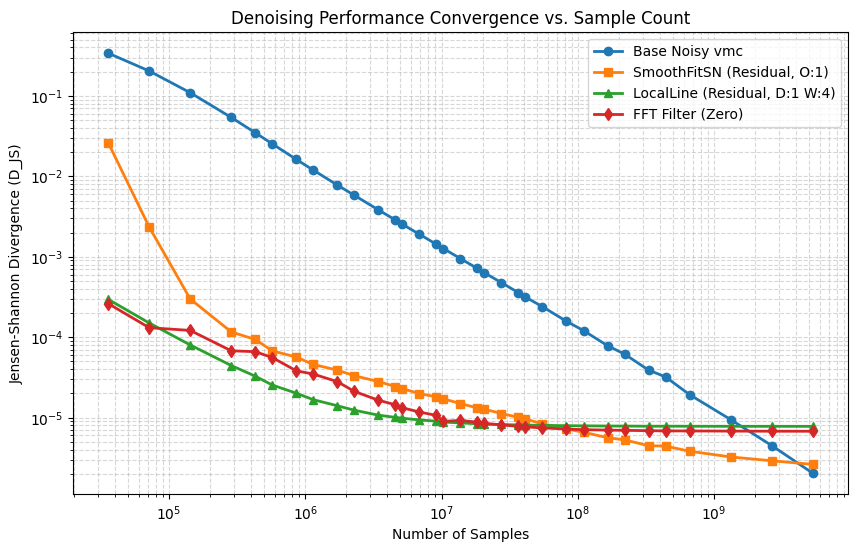

In [1]:
import os
import sys
import glob
import re
import logging  
import h5py
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt

# --- Suppress Matplotlib Debug Output ---
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.ticker').setLevel(logging.WARNING)

# --- Path Setups (Adjust as needed) ---
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/developer_tools') 
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

# Import all three target methods
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
from qmc_algo_tools.density_denoise import DensitySmoothFitLocalLine
from qmc_algo_tools.density_denoise import DensitySmoothFitSN

# =====================================================================
# --- Helper Functions & Metric Calculations ---
# =====================================================================

def D_JS(p1, p2, tol=1e-16):
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    pm = (p1 + p2) / 2
    p1_nonzero = np.abs(p1) > tol
    p2_nonzero = np.abs(p2) > tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5 * ( (p1 * np.log(p1 / pm1)).sum() + (p2 * np.log(p2 / pm2)).sum() )
    d /= np.log(2)
    return d

def transform(density, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return (density - density_ref) / np.sqrt(np.abs(density_ref))
    raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return density_ref + np.sqrt(np.abs(density_ref)) * density_trans
    raise RuntimeError('bad transform type')

# =====================================================================
# --- Main Processing & Plotting Routine ---
# =====================================================================

if __name__ == "__main__":
    # --- 1. Load Reference Data ---
    base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2"
    vmc_ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
    with h5py.File(vmc_ref_path, 'r') as file:
        ref_d = file['density'][:]
    print(f"vmc Ref shape: {ref_d.shape}")

    dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_noJ/density_tot_ref.h5'
    with h5py.File(dft_path, 'r') as file:
        dft_d = file['density'][:]

    # --- 2. Setup Models and Directories ---
    data_dir = "/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2"
    file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
    files = glob.glob(file_pattern)

    print(f"Found {len(files)} files to process.")

    # Initialize Classes with the BEST parameters found in grid search
    # (Fixed FFT initialization by adding filter_mode='zero')

    # diamon path VMC
    vmc_ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5'
    with h5py.File(vmc_ref_path, 'r') as file:
        ref_d = file['density'][:]
    print(f"vmc Ref shape: {ref_d.shape}")

    dft_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
    with h5py.File(dft_path, 'r') as file:
        dft_d = file['density'][:]

    # --- 2. Setup Models and Directories ---
    data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/'
    file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
    files = glob.glob(file_pattern)

    print(f"Found {len(files)} files to process.")

    # Initialize Classes with the BEST parameters found in grid search
    # (Fixed FFT initialization by adding filter_mode='zero')
    # diamon path VMC
    ################################################################################################
    dm_sn  = DensitySmoothFitSN(density_ref=dft_d, smooth=None, order=1, weight='cauchy')
    dm_ll  = DensitySmoothFitLocalLine(density_ref=dft_d, degree=1, window=5)
    dm_fft = DensityFourierFilterErrorCeil(density_ref=dft_d, filter_mode='augment') 
    ################################################################################################

    trans_type = 'residual_noise'
    results = []

    # --- 3. Processing Loop (Full Range) ---
    for counter, fpath in enumerate(files, 1):
        match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
        if not match: 
            continue
        sample_count = int(match.group(1))
        
        print(f"Processing File {counter}/{len(files)} - Samples: {sample_count}")
        
        with h5py.File(fpath, 'r') as f:
            test_d = np.array(f['density'])
        
        # Calculate the residual transformation once per file to save time
        trans_d = transform(test_d, dft_d, trans_type)

        # ----------------------------------------------------
        # Method A: DensitySmoothFitSN (Residual)
        # ----------------------------------------------------
        sn_trans_eval = dm_sn.smoothed_fit(trans_d)
        denoised_sn = inverse_transform(sn_trans_eval, dft_d, trans_type)

        # ----------------------------------------------------
        # Method B: LocalLine (Residual)
        # ----------------------------------------------------
        ll_trans_eval = dm_ll.smoothed_fit(trans_d)
        denoised_ll = inverse_transform(ll_trans_eval, dft_d, trans_type)
        
        # ----------------------------------------------------
        # Method C: FFT (Raw Density)
        # ----------------------------------------------------
        denoised_fft = dm_fft.denoise(test_d)

        # ----------------------------------------------------
        # Calculate and Store Metrics
        # ----------------------------------------------------
        results.append({
            "Samples": sample_count,
            "Noisy_vmc": D_JS(test_d, ref_d),
            "SmoothFitSN": D_JS(denoised_sn, ref_d),
            "LocalLine": D_JS(denoised_ll, ref_d),
            "FFT": D_JS(denoised_fft, ref_d)
        })

        

    # --- 4. Export to CSV ---
    df_results = pd.DataFrame(results)
    
    # Sort by sample count so the CSV and Plot read cleanly from lowest to highest
    df_results = df_results.sort_values(by="Samples").reset_index(drop=True)
    
    csv_filename = "best_parameters_denoising_results.csv"
    df_results.to_csv(csv_filename, index=False)
    
    # --- 5. Plotting Convergence Metrics ---
    plt.figure(figsize=(10, 6))
    plt.plot(df_results["Samples"], df_results["Noisy_vmc"], marker='o', linestyle='-', linewidth=2, label="Base Noisy vmc")
    plt.plot(df_results["Samples"], df_results["SmoothFitSN"], marker='s', linestyle='-', linewidth=2, label="SmoothFitSN (Residual, O:1)")
    plt.plot(df_results["Samples"], df_results["LocalLine"], marker='^', linestyle='-', linewidth=2, label="LocalLine (Residual, D:1 W:4)")
    plt.plot(df_results["Samples"], df_results["FFT"], marker='d', linestyle='-', linewidth=2, label="FFT Filter (Zero)")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of Samples")
    plt.ylabel("Jensen-Shannon Divergence (D_JS)")
    plt.title("Denoising Performance Convergence vs. Sample Count")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    
    plot_filename = "best_parameters_denoising_plot.png"
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    
    print("\n=========================================================")
    print(f"Processing Complete! Results successfully saved to:")
    print(f"-> Data: {csv_filename}")
    print(f"-> Plot: {plot_filename}")
    print("=========================================================")